In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from matplotlib.transforms import offset_copy
from matplotlib import colors

from sklearn.decomposition import PCA

In [2]:
%run LittRuP__import_functions.ipynb

In [3]:
# chemins vers fichiers Data et Images

BASE_DIR = Path.cwd()
DAT_DIR = BASE_DIR / "Data"
IMG_DIR = BASE_DIR / "Images"

In [4]:
# import matrice étendue

matrix_all_extended = pd.read_csv(DAT_DIR / "LittRu_matrix_all_extended.csv", sep=',', header=0)

In [9]:
# SELECTION de la matrice des identifiants étendus (Works...->)

cols_ids_extended = ["Works", "Author", "Birth", "Death", "Period", "Composed", "When", "Name", "CutOff"]

matrix_ids_extended = matrix_all_extended[cols_ids_extended]

In [10]:
# indique que les thèmes sont toutes les colonnes situées après "CutOff"

theme_cols = matrix_all_extended.columns[
    matrix_all_extended.columns.get_loc("CutOff") + 1:
]

In [7]:
# profil thématique par auteur

matrix_author_profile = (
    matrix_all_extended
    .groupby("Author")[theme_cols]   # Regrouper les lignes (thèmes) appartenant au même auteur (=> mis en INDEX !)
    .sum()                           # appliquer une somme colonne par colonne à l’intérieur de chaque groupe d’auteur
)

In [8]:
# normalisation sphérique

author_sphere = (
    matrix_author_profile
    .div(
        np.sqrt((matrix_author_profile**2).sum(axis=1)),
        axis=0
    )
)

**ACP des auteurs (variances des axes)**

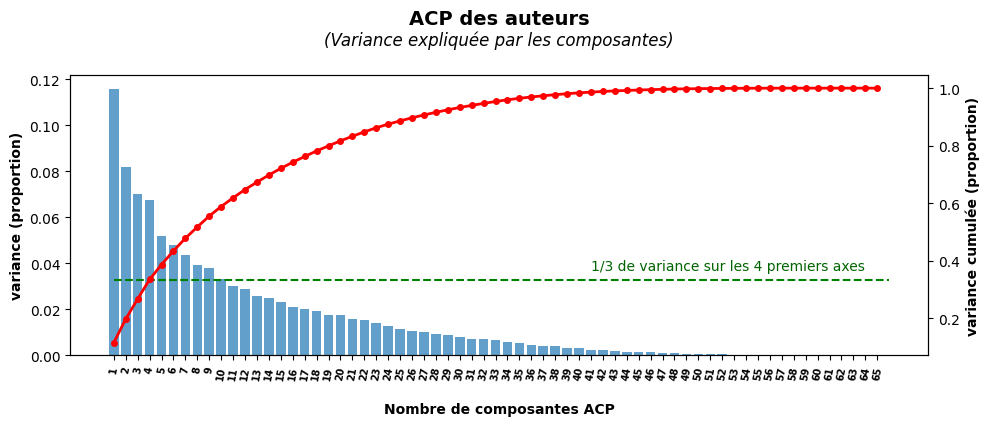

In [11]:

X_tot = author_sphere.copy()

# le nombre maximal de composantes calculabes est min(n_samples - 1 , n_features)

max_comp = min(X_tot.shape[0] - 1, X_tot.shape[1] )

pca_tot = PCA(n_components = max_comp)

pca_tot.fit(X_tot)

var = pca_tot.explained_variance_ratio_

fig, ax1 = plt.subplots(figsize=(10, 4))

xs = range(max_comp)
labels_xs=[i+1 for i in list(xs)]
ax1.bar(x=xs, height=var, alpha=0.7, label="variance par axe (%)")
ax1.set_xlabel("\nNombre de composantes ACP", fontweight="bold")
ax1.set_ylabel("variance (proportion)", fontweight="bold")
ax1.set_xticks(xs, labels_xs, fontsize=7, fontweight="bold", rotation=80)

cum_var = np.cumsum(var)

ax2 = ax1.twinx()
ax2.plot(xs, cum_var, color="red", marker="o", ms=4, linewidth=2, label="variance cumulée")
ax2.set_ylabel("variance cumulée (proportion)", fontweight="bold")

ax2.hlines(
    y=0.333,
    xmin=0,
    xmax=65,
    color="green",
    linestyle="--",
    linewidth=1.5,
    zorder=0
)
trans = offset_copy(ax2.transData, fig=fig, x=0, y=5, units='points')
# note : dans offset_copy, x et y ne sont pas les coordonnées du texte. 
# Ce sont des décalages par rapport au point donné dans ax2.text(...).
ax2.text(
    40,
    0.3333,
    "1/3 de variance sur les 4 premiers axes",
    transform=trans,
    rotation=0,
    va="bottom",
    fontsize=10,
    color="darkgreen"
)

fig.tight_layout(rect=[0, 0, 1, 0.93])

titres(fig, ax1,
    t1="ACP des auteurs", y1=37,
    t2="(Variance expliquée par les composantes)", y2=22,
    t3=" ", y3=7
)

fig.savefig(IMG_DIR / "auteurs_ACP_variances_expliquées.png", dpi=300)

plt.show()

**ACP des auteurs (sans StandardScaler)**

In [12]:
X = author_sphere.copy()

# réaliser la PCA
pca = PCA(n_components=2)

# contient les coordonnées des auteurs sur les deux axes PCA
row_coords = pca.fit_transform(X)

# Pourcentage de variance expliqué
PC1, PC2 = pca.explained_variance_ratio_

# coordonnées des auteurs dans le plan ACP
author_coords = pd.DataFrame(
    row_coords,
    columns=["PC1", "PC2"],
    index=author_sphere.index
)

# distance à l'origine : mesure visuelle de contribution/importance sur le plan
author_coords["dist_origin"] = np.sqrt(
    author_coords["PC1"]**2 + author_coords["PC2"]**2
)


**Axes 1 et 2**

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


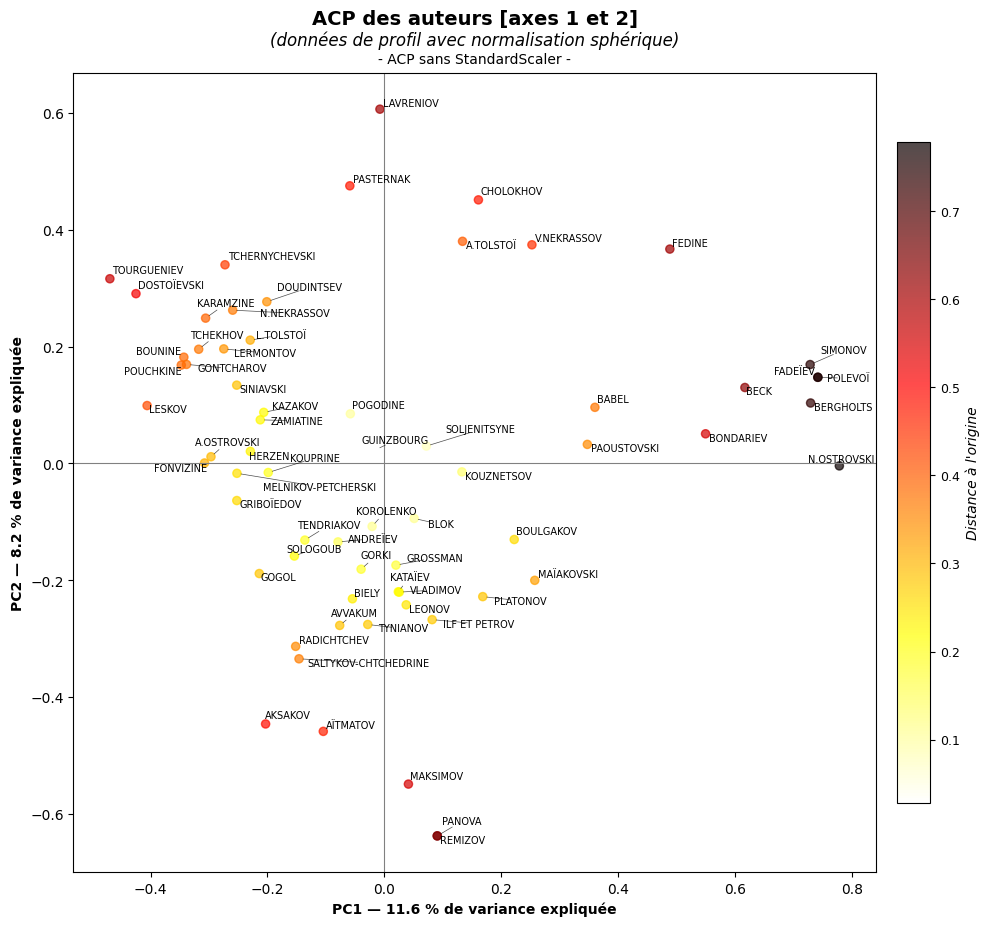

In [13]:
X = author_sphere.copy()

# réaliser la PCA
pca = PCA(n_components=2)

# contient les coordonnées des auteurs sur les deux axes PCA
row_coords = pca.fit_transform(X)

# Pourcentage de variance expliqué
PC1, PC2 = pca.explained_variance_ratio_

# coordonnées des auteurs dans le plan ACP
author_coords = pd.DataFrame(
    row_coords,
    columns=["PC1", "PC2"],
    index=author_sphere.index
)

# distance à l'origine : mesure visuelle de contribution/importance sur le plan
author_coords["dist_origin"] = np.sqrt(
    author_coords["PC1"]**2 + author_coords["PC2"]**2
)

import io
import contextlib
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(10, 10))

scatter = ax.scatter(
    author_coords["PC1"],
    author_coords["PC2"],
    c=author_coords["dist_origin"],
    cmap="hot_r",
    s=35,
    alpha=0.7,
    zorder=1
)

texts = []

for author in author_coords.index:
    texts.append(
        ax.text(
            author_coords.loc[author, "PC1"],
            author_coords.loc[author, "PC2"],
            author,
            fontsize=7,
            color="black",
            zorder=3
        )
    )

with contextlib.redirect_stdout(io.StringIO()):
    adjust_text(
        texts,
        ax=ax,
        x=author_coords["PC1"],
        y=author_coords["PC2"],
        expand_text=(1.2, 1.4),
        expand_points=(1.4, 1.6),
        force_text=(0.4, 0.6),
        force_points=(0.3, 0.5),
        arrowprops=dict(
            arrowstyle="-",
            color="black",
            lw=0.5,
            alpha=0.7,
            shrinkA=8,
            shrinkB=3
        )
    )

ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(0, color="grey", linewidth=0.8)

ax.set_xlabel(f"PC1 — {PC1*100:.1f} % de variance expliquée", fontsize=10, fontweight='bold')
ax.set_ylabel(f"PC2 — {PC2*100:.1f} % de variance expliquée", fontsize=10, fontweight='bold')

ax.set_aspect("equal")

cbar = plt.colorbar(
    scatter,
    ax=ax,
    shrink=0.75,     # raccourcit la barre à x % de sa hauteur
    fraction=0.045,  # barre plus mince
    pad=0.025        # rapproche légèrement la barre du graphique
)
cbar.ax.tick_params(labelsize=9)
cbar.set_label("Distance à l'origine", fontsize=10, fontstyle="italic")

fig.tight_layout(rect=[0, 0, 1, 0.93])

titres(fig, ax,
    t1="ACP des auteurs [axes 1 et 2]", y1=35,
    t2="(données de profil avec normalisation sphérique)", y2=20,
    t3="- ACP sans StandardScaler -", y3=7
)

fig.savefig(IMG_DIR / "auteurs_ACP_PC1_PC2.png", dpi=300)

plt.show()

**Coefficients des thèmes dans les composantes principales**

In [14]:
# Chaque axe principal est une combinaison linéaire des thèmes. 
# Les coefficients contenus dans pca.components_ indiquent le poids de chaque thème dans 
# la construction de PC1 et PC2 ; par exemple : PC1 = a1 × Amour + a2 × Argent + a3 × Dieu + ...
# et theme_coords.loc["Amour", "PC1"] est le coefficient associé au thème Amour dans cette combinaison.

theme_coords = pd.DataFrame(
    pca.components_.T[:, :2],
    index=author_sphere.columns,
    columns=["PC1", "PC2"]
)

In [15]:
# afficher seulement les thèmes les mieux représentés sur les axes 1 et 2.

TOP = 10

theme_coords["distance à l'origine"] = np.sqrt(
    theme_coords["PC1"]**2 + theme_coords["PC2"]**2
)

theme_coords_top = theme_coords.sort_values("distance à l'origine", ascending=False).head(TOP)

In [16]:
theme_coords_top

,PC1,PC2,distance à l'origine
Guerre,0.567348,0.375260,0.680223
Amour,-0.344241,0.543912,0.643694
Femme,-0.291620,0.441474,0.529095
Apprentissage,0.058597,-0.458485,0.462215
Patrie,0.383098,0.125168,0.403028
Communisme,0.279994,0.108587,0.300313
Société,0.194582,-0.045295,0.199784
Héros,0.189783,0.044194,0.194861
Traditions,-0.141339,-0.128545,0.191052
Noblesse,-0.164020,-0.072712,0.179415


In [18]:
# Les axes de l’ACP sont interprétés à partir des coefficients des thèmes dans les composantes principales. 
# Les thèmes ayant les coefficients les plus élevés, en valeur absolue, 
# sont ceux qui participent le plus à la construction de l’axe considéré.

theme_weights = pd.DataFrame(
    pca.components_[:2].T,
    index=author_sphere.columns,
    columns=["PC1", "PC2"]
)

theme_weights["abs_PC1"] = theme_weights["PC1"].abs()
theme_weights["abs_PC2"] = theme_weights["PC2"].abs()

top_PC1 = theme_weights.sort_values("abs_PC1", ascending=False).head(TOP)
top_PC2 = theme_weights.sort_values("abs_PC2", ascending=False).head(TOP)

**Axes 1 et 2 avec flèches de thèmes**

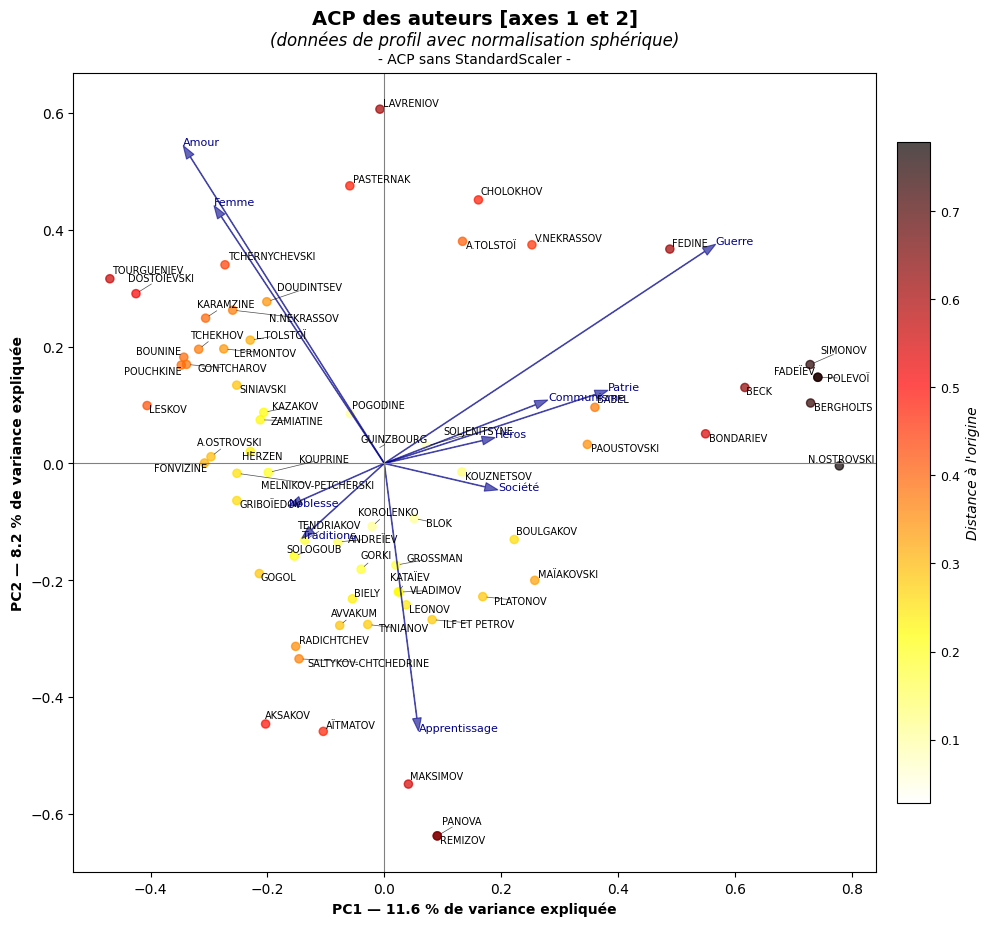

In [19]:
import io
import contextlib
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(10, 10))

scatter = ax.scatter(
    author_coords["PC1"],
    author_coords["PC2"],
    c=author_coords["dist_origin"],
    cmap="hot_r",
    s=35,
    alpha=0.7,
    zorder=1
)

texts = []

for author in author_coords.index:
    texts.append(
        ax.text(
            author_coords.loc[author, "PC1"],
            author_coords.loc[author, "PC2"],
            author,
            fontsize=7,
            color="black",
            zorder=3
        )
    )

with contextlib.redirect_stdout(io.StringIO()):
    adjust_text(
        texts,
        ax=ax,
        x=author_coords["PC1"],
        y=author_coords["PC2"],
        expand_text=(1.2, 1.4),
        expand_points=(1.4, 1.6),
        force_text=(0.4, 0.6),
        force_points=(0.3, 0.5),
        arrowprops=dict(
            arrowstyle="-",
            color="black",
            lw=0.5,
            alpha=0.7,
            shrinkA=8,
            shrinkB=3
        )
    )

ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(0, color="grey", linewidth=0.8)

ax.set_xlabel(f"PC1 — {PC1*100:.1f} % de variance expliquée", fontsize=10, fontweight='bold')
ax.set_ylabel(f"PC2 — {PC2*100:.1f} % de variance expliquée", fontsize=10, fontweight='bold')

ax.set_aspect("equal")

cbar = plt.colorbar(
    scatter,
    ax=ax,
    shrink=0.75,     # raccourcit la barre à x % de sa hauteur
    fraction=0.045,  # barre plus mince
    pad=0.025        # rapproche légèrement la barre du graphique
)
cbar.ax.tick_params(labelsize=9)
cbar.set_label("Distance à l'origine", fontsize=10, fontstyle="italic")


scale_theme = 1.0  # à ajuster selon le rendu

for theme in theme_coords_top.index:
    x = theme_coords.loc[theme, "PC1"] * scale_theme
    y = theme_coords.loc[theme, "PC2"] * scale_theme
    
    ax.arrow(
        0, 0,
        x, y,
        color="darkblue",
        alpha=0.6,
        linewidth=0.8,
        head_width=0.015,
        length_includes_head=True
    )
    
    ax.text(
        x,
        y,
        theme,
        fontsize=8,
        color="darkblue"
    )

fig.tight_layout(rect=[0, 0, 1, 0.93])

titres(fig, ax,
    t1="ACP des auteurs [axes 1 et 2]", y1=35,
    t2="(données de profil avec normalisation sphérique)", y2=20,
    t3="- ACP sans StandardScaler -", y3=7
)

fig.savefig(IMG_DIR / "auteurs_ACP_PC1_PC2_flèches.png", dpi=300)

plt.show()

**Axes 3 et 4 (annexe)**

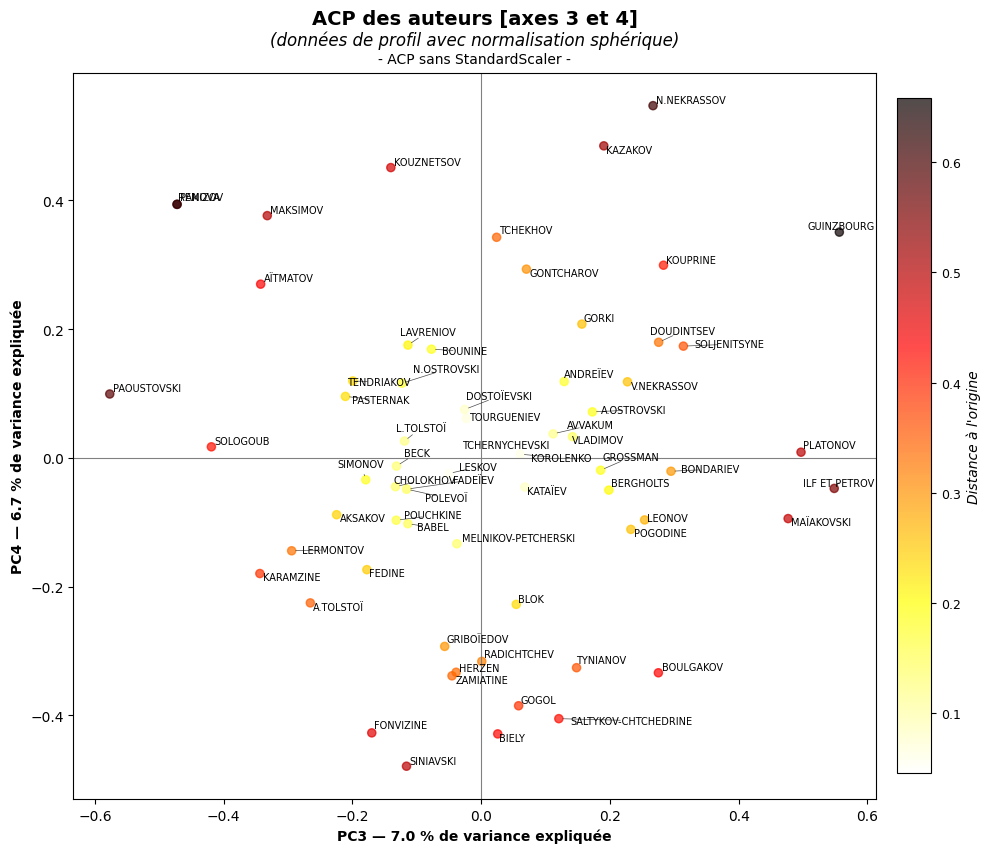

In [20]:
X = author_sphere.copy()

# réaliser la PCA
pca = PCA(n_components=4)

# contient les coordonnées des auteurs sur les deux axes PCA
row_coords = pca.fit_transform(X)

# Pourcentage de variance expliqué
PC1, PC2, PC3, PC4 = pca.explained_variance_ratio_

# coordonnées des auteurs dans le plan ACP
author_coords = pd.DataFrame(
    row_coords,
    columns=["PC1", "PC2", "PC3", "PC4"],
    index=author_sphere.index
)

# distance à l'origine : mesure visuelle de contribution/importance sur le plan
author_coords["dist_origin"] = np.sqrt(
    author_coords["PC3"]**2 + author_coords["PC4"]**2
)

import io
import contextlib
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(10, 10))

scatter = ax.scatter(
    author_coords["PC3"],
    author_coords["PC4"],
    c=author_coords["dist_origin"],
    cmap="hot_r",
    s=35,
    alpha=0.7,
    zorder=1
)

texts = []

for author in author_coords.index:
    texts.append(
        ax.text(
            author_coords.loc[author, "PC3"],
            author_coords.loc[author, "PC4"],
            author,
            fontsize=7,
            color="black",
            zorder=3
        )
    )

with contextlib.redirect_stdout(io.StringIO()):
    adjust_text(
        texts,
        ax=ax,
        x=author_coords["PC3"],
        y=author_coords["PC4"],
        expand_text=(1.2, 1.4),
        expand_points=(1.4, 1.6),
        force_text=(0.4, 0.6),
        force_points=(0.3, 0.5),
        arrowprops=dict(
            arrowstyle="-",
            color="black",
            lw=0.5,
            alpha=0.7,
            shrinkA=8,
            shrinkB=3

        )
    )

ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(0, color="grey", linewidth=0.8)

ax.set_xlabel(f"PC3 — {PC3*100:.1f} % de variance expliquée", fontsize=10, fontweight='bold')
ax.set_ylabel(f"PC4 — {PC4*100:.1f} % de variance expliquée", fontsize=10, fontweight='bold')

ax.set_aspect("equal")

cbar = plt.colorbar(
    scatter,
    ax=ax,
    shrink=0.75,     # raccourcit la barre à x % de sa hauteur
    fraction=0.045,  # barre plus mince
    pad=0.025        # rapproche légèrement la barre du graphique
)
cbar.ax.tick_params(labelsize=9)
cbar.set_label("Distance à l'origine", fontsize=10, fontstyle="italic")

fig.tight_layout(rect=[0, 0, 1, 0.93])

titres(fig, ax,
    t1="ACP des auteurs [axes 3 et 4]", y1=35,
    t2="(données de profil avec normalisation sphérique)", y2=20,
    t3="- ACP sans StandardScaler -", y3=7
)

fig.savefig(IMG_DIR / "auteurs_ACP_PC3_PC4.png", dpi=300)

plt.show()

In [21]:
# Chaque axe principal est une combinaison linéaire des thèmes. 
# Les coefficients contenus dans pca.components_ indiquent le poids de chaque thème dans 
# la construction de PC3 et PC4 ; par exemple : PC3 = a1 × Amour + a2 × Argent + a3 × Dieu + ...
# et theme_coords.loc["Amour", "PC3"] est le coefficient associé au thème Amour dans cette combinaison.

theme_coords = pd.DataFrame(
    pca.components_.T[:, [2,3]],
    index=author_sphere.columns,
    columns=["PC3", "PC4"]
)

In [22]:
# afficher seulement les thèmes les mieux représentés sur les axes 1 et 2.

theme_coords["distance à l'origine"] = np.sqrt(
    theme_coords["PC3"]**2 + theme_coords["PC4"]**2
)

theme_coords_top = theme_coords.sort_values("distance à l'origine", ascending=False).head(10)
theme_coords_top

,PC3,PC4,distance à l'origine
Apprentissage,-0.528980,0.419443,0.675094
Femme,0.210425,0.572734,0.610166
Société,0.530075,0.034845,0.531219
Fantastique,0.066460,-0.399692,0.405180
Amour,-0.310508,-0.241535,0.393388
Nature,-0.255677,0.023589,0.256762
Noblesse,-0.065918,-0.220628,0.230265
Médiocrité,0.204176,-0.066490,0.214729
Guerre,-0.194905,0.016492,0.195602
Occident,-0.026770,-0.184044,0.185981
